# 04 — Model Comparison

Loads all saved experiments, evaluates each on the current test set, and produces:
- Results table (PSNR, SSIM, LPIPS) across all models
- Per-AOI breakdown
- Side-by-side visual comparison

In [1]:
import sys, json
from pathlib import Path

sys.path.insert(0, str(Path('../src').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips

from model import SuperResCNN
from degrade import bicubic_upscale

%matplotlib inline

EXP_ROOT = Path('../experiments')
MANIFEST = Path('../data/manifest.csv')
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

# LPIPS network (AlexNet-based, lightweight)
lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)

print(f'Device: {DEVICE}')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/Users/grahambillington/Documents/ClearformLabs/planet-superres/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/grahambillington/Documents/ClearformLabs/planet-superres/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /Users/grahambillington/Documents/ClearformLabs/planet-superres/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
Device: mps


## Step 1: Load test set and experiments

In [2]:
manifest = pd.read_csv(MANIFEST)
test_df = manifest[manifest['split'] == 'test'].reset_index(drop=True)
print(f'Test tiles: {len(test_df)}')
print(f'Test AOIs: {sorted(test_df["aoi"].unique())}')

# Find experiments that have a saved model
experiments = {}
for exp_dir in sorted(EXP_ROOT.iterdir()):
    config_path = exp_dir / 'config.json'
    model_path = exp_dir / 'model.pth'
    if config_path.exists() and model_path.exists():
        with open(config_path) as f:
            config = json.load(f)
        experiments[exp_dir.name] = {'config': config, 'dir': exp_dir}
        print(f'  {exp_dir.name}: {config["n_resblocks"]} blocks, {config["n_feats"]} feats, scale={config["scale"]}')

print(f'\n{len(experiments)} experiments found')

Test tiles: 282
Test AOIs: ['chicago-urban', 'sd-terrain-and-river']
  v1_l1_only_4x: 4 blocks, 64 feats, scale=4
  v2_perceptual_4x: 4 blocks, 64 feats, scale=4
  v3_more_data_4x: 6 blocks, 96 feats, scale=4

3 experiments found


## Step 2: Evaluate all models on test set

In [3]:
def evaluate_model(model, test_df, scale, device):
    """Compute PSNR, SSIM, LPIPS for a model on the test set."""
    model.eval()
    records = []

    with torch.no_grad():
        for _, row in test_df.iterrows():
            lr_np = np.array(Image.open(row['lr_path']))
            hr_np = np.array(Image.open(row['hr_path']))
            bic_np = bicubic_upscale(lr_np, scale=scale)

            # CNN prediction
            lr_t = torch.from_numpy(lr_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
            pred_t = model(lr_t.to(device)).cpu()
            pred_np = (pred_t[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

            # PSNR / SSIM
            cnn_p = psnr(hr_np, pred_np, data_range=255)
            cnn_s = ssim(hr_np, pred_np, data_range=255, channel_axis=2)
            bic_p = psnr(hr_np, bic_np, data_range=255)
            bic_s = ssim(hr_np, bic_np, data_range=255, channel_axis=2)

            # LPIPS (expects tensors in [-1, 1])
            hr_t  = torch.from_numpy(hr_np).permute(2, 0, 1).float().unsqueeze(0) / 127.5 - 1.0
            pred_lp = pred_t * 2.0 - 1.0
            bic_t = torch.from_numpy(bic_np).permute(2, 0, 1).float().unsqueeze(0) / 127.5 - 1.0
            cnn_l = lpips_fn(pred_lp.to(device), hr_t.to(device)).item()
            bic_l = lpips_fn(bic_t.to(device), hr_t.to(device)).item()

            records.append({
                'aoi': row['aoi'],
                'cnn_psnr': cnn_p, 'cnn_ssim': cnn_s, 'cnn_lpips': cnn_l,
                'bic_psnr': bic_p, 'bic_ssim': bic_s, 'bic_lpips': bic_l,
            })

    return pd.DataFrame(records)

print('Evaluation function ready')

Evaluation function ready


In [4]:
all_results = {}

for name, exp in experiments.items():
    print(f'Evaluating {name}...')
    cfg = exp['config']

    model = SuperResCNN(
        scale=cfg['scale'],
        n_resblocks=cfg['n_resblocks'],
        n_feats=cfg['n_feats'],
    ).to(DEVICE)
    model.load_state_dict(torch.load(exp['dir'] / 'model.pth', map_location=DEVICE))

    df = evaluate_model(model, test_df, scale=cfg['scale'], device=DEVICE)
    all_results[name] = df
    print(f'  PSNR: {df["cnn_psnr"].mean():.2f}  SSIM: {df["cnn_ssim"].mean():.4f}  LPIPS: {df["cnn_lpips"].mean():.4f}')

print('\nDone')

Evaluating v1_l1_only_4x...
  PSNR: 22.90  SSIM: 0.5966  LPIPS: 0.5072
Evaluating v2_perceptual_4x...
  PSNR: 22.92  SSIM: 0.6000  LPIPS: 0.4869
Evaluating v3_more_data_4x...
  PSNR: 23.14  SSIM: 0.6160  LPIPS: 0.4703

Done


## Step 3: Results table

In [5]:
# Build summary table
rows = []

# Bicubic baseline (same across all experiments with same scale)
first_df = list(all_results.values())[0]
rows.append({
    'Experiment': 'Bicubic (baseline)',
    'PSNR (dB)': first_df['bic_psnr'].mean(),
    'SSIM': first_df['bic_ssim'].mean(),
    'LPIPS': first_df['bic_lpips'].mean(),
})

for name, df in all_results.items():
    rows.append({
        'Experiment': name,
        'PSNR (dB)': df['cnn_psnr'].mean(),
        'SSIM': df['cnn_ssim'].mean(),
        'LPIPS': df['cnn_lpips'].mean(),
    })

summary = pd.DataFrame(rows)
summary['Delta PSNR'] = summary['PSNR (dB)'] - summary.iloc[0]['PSNR (dB)']

# Format nicely
styled = summary.round({'PSNR (dB)': 2, 'SSIM': 4, 'LPIPS': 4, 'Delta PSNR': 2})
print(styled.to_string(index=False))

# Save
styled.to_csv(FIGURES_DIR / 'results_table.csv', index=False)
print(f'\nSaved to {FIGURES_DIR / "results_table.csv"}')

        Experiment  PSNR (dB)   SSIM  LPIPS  Delta PSNR
Bicubic (baseline)      22.24 0.5010 0.6224        0.00
     v1_l1_only_4x      22.90 0.5966 0.5072        0.66
  v2_perceptual_4x      22.92 0.6000 0.4869        0.67
   v3_more_data_4x      23.14 0.6160 0.4703        0.90

Saved to ../figures/results_table.csv


## Step 4: Per-AOI breakdown (best model)

Per-AOI breakdown for: v3_more_data_4x

                      cnn_psnr  cnn_ssim  cnn_lpips  bic_psnr  bic_ssim  delta_psnr
aoi                                                                                
chicago-urban          18.3266    0.6759     0.3022   16.7911    0.4875        1.54
sd-terrain-and-river   27.8897    0.5569     0.6361   27.6220    0.5143        0.27


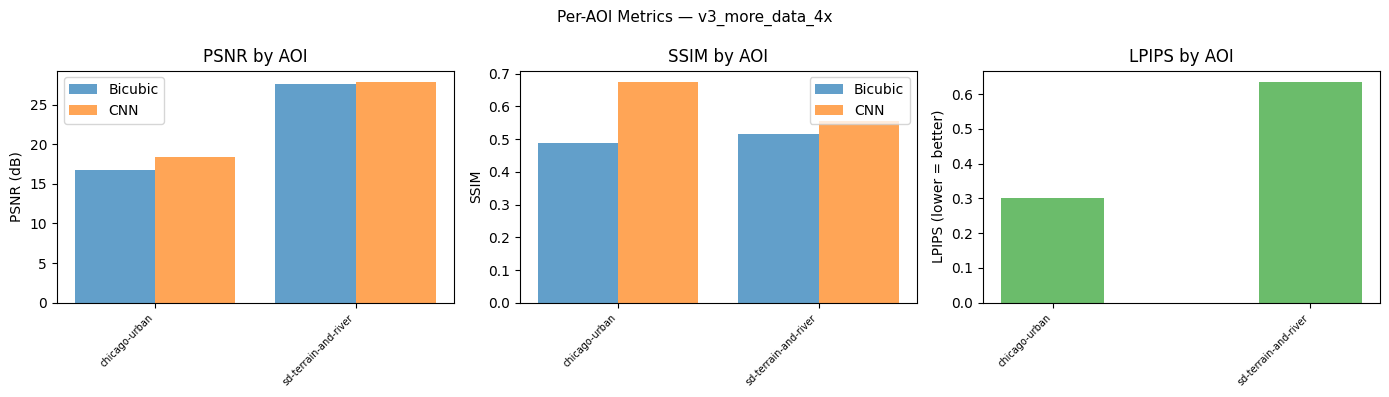

In [6]:
# Use the last experiment as "best"
best_name = list(all_results.keys())[-1]
best_df = all_results[best_name]

print(f'Per-AOI breakdown for: {best_name}\n')

aoi_summary = best_df.groupby('aoi').agg({
    'cnn_psnr': 'mean', 'cnn_ssim': 'mean', 'cnn_lpips': 'mean',
    'bic_psnr': 'mean', 'bic_ssim': 'mean',
}).round(4)

aoi_summary['delta_psnr'] = (aoi_summary['cnn_psnr'] - aoi_summary['bic_psnr']).round(2)
print(aoi_summary.to_string())

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

aois = aoi_summary.index.tolist()
x = range(len(aois))

axes[0].bar(x, aoi_summary['bic_psnr'], width=0.4, label='Bicubic', alpha=0.7)
axes[0].bar([i+0.4 for i in x], aoi_summary['cnn_psnr'], width=0.4, label='CNN', alpha=0.7)
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('PSNR by AOI')
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(aois, rotation=45, ha='right', fontsize=7)
axes[0].legend()

axes[1].bar(x, aoi_summary['bic_ssim'], width=0.4, label='Bicubic', alpha=0.7)
axes[1].bar([i+0.4 for i in x], aoi_summary['cnn_ssim'], width=0.4, label='CNN', alpha=0.7)
axes[1].set_ylabel('SSIM')
axes[1].set_title('SSIM by AOI')
axes[1].set_xticks([i+0.2 for i in x])
axes[1].set_xticklabels(aois, rotation=45, ha='right', fontsize=7)
axes[1].legend()

axes[2].bar(x, aoi_summary['cnn_lpips'], width=0.4, color='tab:green', alpha=0.7)
axes[2].set_ylabel('LPIPS (lower = better)')
axes[2].set_title('LPIPS by AOI')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(aois, rotation=45, ha='right', fontsize=7)

plt.suptitle(f'Per-AOI Metrics — {best_name}', fontsize=11)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'per_aoi_metrics.png', bbox_inches='tight')
plt.show()

## Step 5: Visual comparison across models

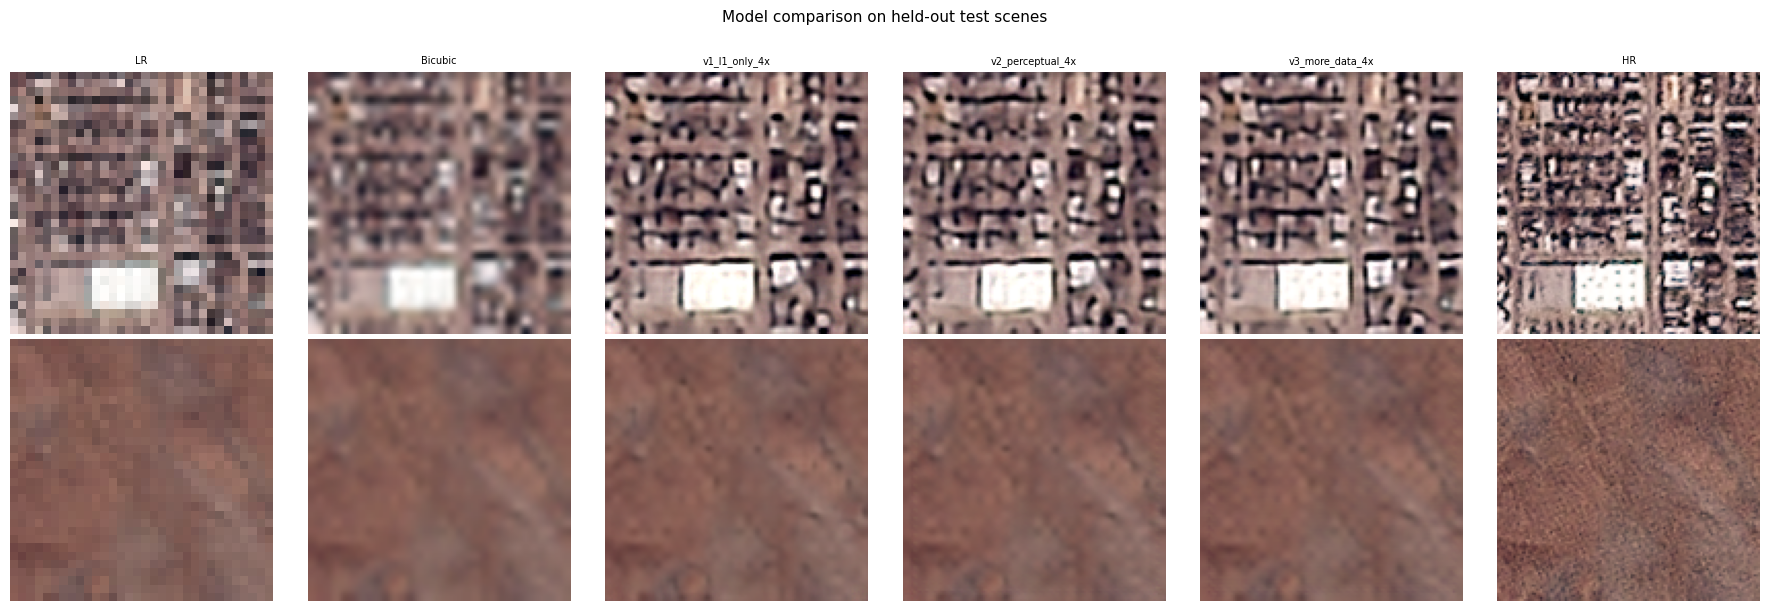

In [7]:
# Pick one test tile per AOI
test_aois = sorted(test_df['aoi'].unique())
sample_rows = [test_df[test_df['aoi'] == aoi].iloc[0] for aoi in test_aois]

n_models = len(experiments)
n_cols = 2 + n_models  # LR, bicubic, model1, model2, ..., HR (at end)
n_cols_total = n_cols + 1  # +1 for HR

fig, axes = plt.subplots(len(sample_rows), n_cols_total, figsize=(3 * n_cols_total, 3 * len(sample_rows)))

col_labels = ['LR', 'Bicubic'] + list(experiments.keys()) + ['HR']
for col, label in enumerate(col_labels):
    axes[0, col].set_title(label, fontsize=7)

# Load all models
models = {}
for name, exp in experiments.items():
    cfg = exp['config']
    m = SuperResCNN(scale=cfg['scale'], n_resblocks=cfg['n_resblocks'], n_feats=cfg['n_feats']).to(DEVICE)
    m.load_state_dict(torch.load(exp['dir'] / 'model.pth', map_location=DEVICE))
    m.eval()
    models[name] = (m, cfg['scale'])

for row_idx, sample in enumerate(sample_rows):
    lr_np = np.array(Image.open(sample['lr_path']))
    hr_np = np.array(Image.open(sample['hr_path']))
    bic_np = bicubic_upscale(lr_np, scale=4)

    images = [lr_np, bic_np]
    for name, (m, scale) in models.items():
        lr_t = torch.from_numpy(lr_np).permute(2, 0, 1).float().unsqueeze(0) / 255.0
        with torch.no_grad():
            pred = m(lr_t.to(DEVICE)).cpu()
        pred_np = (pred[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
        images.append(pred_np)
    images.append(hr_np)

    for col, img in enumerate(images):
        axes[row_idx, col].imshow(img)
        axes[row_idx, col].axis('off')
    axes[row_idx, 0].set_ylabel(sample['aoi'], fontsize=7, rotation=90, labelpad=40)

plt.suptitle('Model comparison on held-out test scenes', fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'model_comparison.png', bbox_inches='tight')
plt.show()

## Step 6: Out-of-distribution test

Run the best model on a non-satellite image (e.g. a photo of a cat) to see how it handles data it was never trained on.

In [8]:
# Download a sample image if one doesn't exist
OOD_PATH = Path('../data/raw/ood_test.jpg')

if not OOD_PATH.exists():
    print('Place any JPG/PNG image at data/raw/ood_test.jpg and re-run this cell')
else:
    from tiling import load_image

    ood_img = load_image(OOD_PATH)
    # Crop a 128x128 patch from the center
    h, w = ood_img.shape[:2]
    cy, cx = h // 2, w // 2
    hr_patch = ood_img[cy-64:cy+64, cx-64:cx+64]

    # Create LR and run model
    from degrade import degrade
    lr_patch = degrade(hr_patch, scale=4)
    bic_patch = bicubic_upscale(lr_patch, scale=4)

    best_name = list(models.keys())[-1]
    best_model, best_scale = models[best_name]
    lr_t = torch.from_numpy(lr_patch).permute(2, 0, 1).float().unsqueeze(0) / 255.0
    with torch.no_grad():
        pred_t = best_model(lr_t.to(DEVICE)).cpu()
    pred_patch = (pred_t[0].permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    for ax, img, title in zip(axes,
        [lr_patch, bic_patch, pred_patch, hr_patch],
        ['LR (32x32)', 'Bicubic', f'CNN ({best_name})', 'HR ground truth']):
        ax.imshow(img)
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    ood_psnr = psnr(hr_patch, pred_patch, data_range=255)
    ood_ssim_val = ssim(hr_patch, pred_patch, data_range=255, channel_axis=2)
    bic_psnr_val = psnr(hr_patch, bic_patch, data_range=255)
    plt.suptitle(f'Out-of-distribution test — CNN PSNR: {ood_psnr:.2f} vs Bicubic: {bic_psnr_val:.2f}', fontsize=10)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'ood_test.png', bbox_inches='tight')
    plt.show()

Place any JPG/PNG image at data/raw/ood_test.jpg and re-run this cell
